#### The preprocessing pipeline 

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

#### reading data from files

In [19]:
classification_train = '/home/taha/Desktop/folder/work/brain tumor/brisc2025/classification_task/train'
classification_test = '/home/taha/Desktop/folder/work/brain tumor/brisc2025/classification_task/test'

In [20]:
path = []
labels = []

for label in os.listdir(classification_train):
    label_path = os.path.join(classification_train,label)
    if os.path.isdir(label_path):
        for img in os.listdir(label_path):
            if img.lower().endswith(('.png','jpg','.jpeg')):
                path.append(os.path.join(label_path,img))
                labels.append(label)

df = pd.DataFrame({"image_path" : path,"labels" : labels})

In [9]:
df.head(5)

,image_path,labels
0,/home/taha/Desktop/folder/work/brain tumor/bri...,meningioma
1,/home/taha/Desktop/folder/work/brain tumor/bri...,meningioma
2,/home/taha/Desktop/folder/work/brain tumor/bri...,meningioma
3,/home/taha/Desktop/folder/work/brain tumor/bri...,meningioma
4,/home/taha/Desktop/folder/work/brain tumor/bri...,meningioma


### there is no duplicated data

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

image_path    0
labels        0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  5000 non-null   object
 1   labels      5000 non-null   object
dtypes: object(2)
memory usage: 78.2+ KB


In [13]:
df['labels'].value_counts()

labels
pituitary     1457
meningioma    1329
glioma        1147
no_tumor      1067
Name: count, dtype: int64

<Axes: xlabel='labels', ylabel='count'>

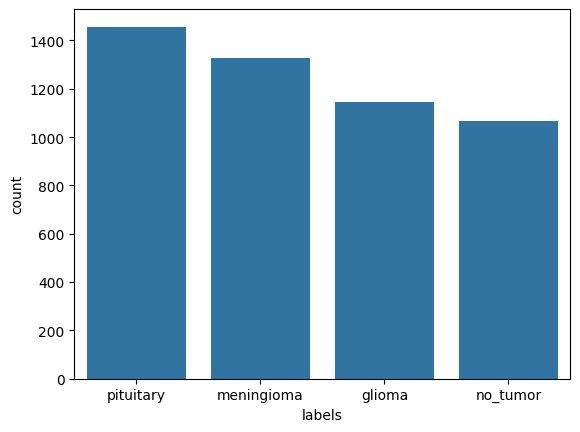

In [18]:
sns.barplot(df['labels'].value_counts())

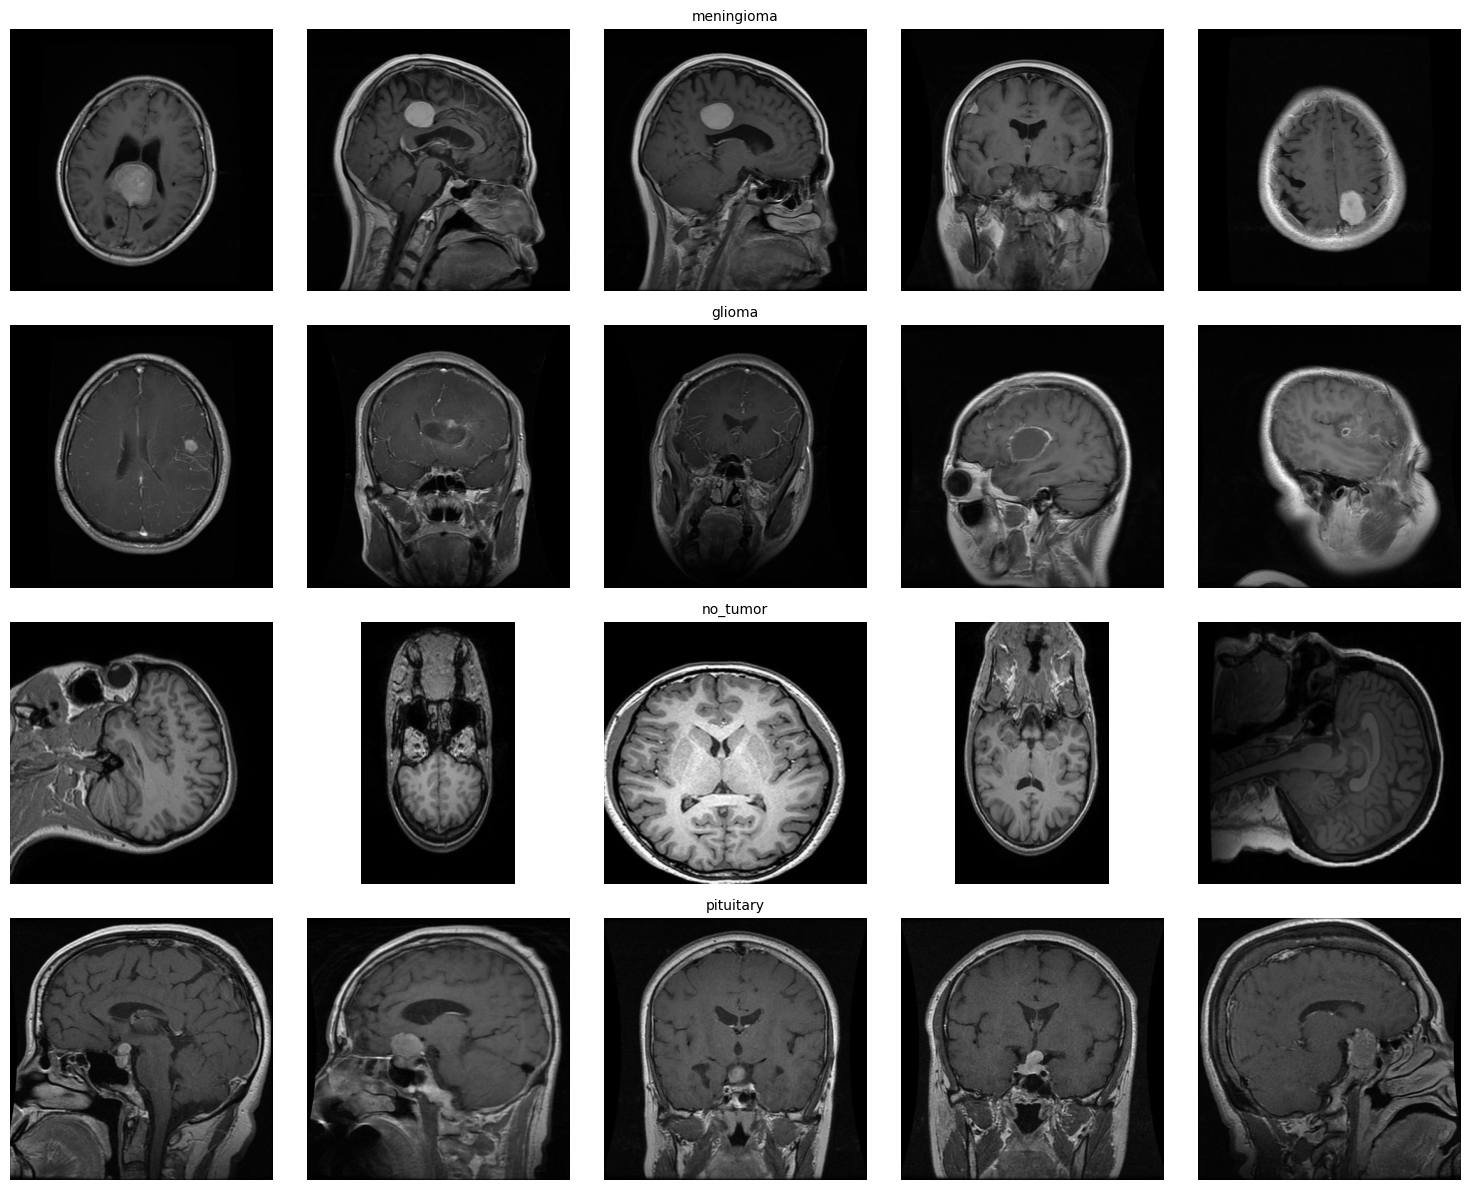

In [26]:
num = 5 
unique_label = df['labels'].unique()
plt.figure(figsize=(15, (len(unique_label)*3)))
for row_idx, label in enumerate(unique_label):
    label_img = df[df['labels'] == label].head(num)['image_path'].tolist()
    for col_idx,img_path in enumerate(label_img):
        plt_idx = row_idx * num +col_idx + 1
        plt.subplot(len(unique_label),num, plt_idx)
        img = Image.open(img_path)
        plt.imshow(img,cmap='gray')
        plt.axis('off')
        if col_idx == 2:
            plt.title(label,fontsize = 10)

plt.tight_layout()
plt.show()


#### implementing ConvNeXt 

In [12]:
import tensorflow as tf
from tensorflow.keras import layers
class ConvNeXtBlock(tf.keras.layers.Layer):
    def __init__(self, dim):
        super().__init__()

        self.dwconv = tf.keras.layers.DepthwiseConv2D(
            kernel_size=7,
            padding="same"
        )
        self.norm = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.pwconv1 = tf.keras.layers.Dense(4 * dim)
        self.act = tf.keras.layers.Activation("gelu")
        self.pwconv2 = tf.keras.layers.Dense(dim)
    def call(self, x):
        shortcut = x
        x = self.dwconv(x)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        x = x + shortcut
        return x

In [5]:
def Downsample(x,out_ch):
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Conv2D(\
        out_ch,
        kernel_size=2,
        strides=2
        )(x)
    return x

In [14]:
def Stem(inputs):
    x = layers.Conv2D(
        96,
        kernel_size=4,
        strides=4
    )(inputs)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x

In [45]:
def Stage(x, ch, depth):
    blocks = []
    for _ in range(depth):
        blocks.append(
            ConvNeXtBlock(ch)
        )
    for block in blocks:
        x = block(x)

    return x

In [32]:
inputs = tf.keras.Input((512,512,3))

x = Stem(inputs)

x = Stage(x,96,3)

x = Downsample(x,192)

x = Stage(x,192,3)

x = Downsample(x,384)

x = Stage(x,384,9)

x = Downsample(x,768)

x = Stage(x,768,3)

x = layers.GlobalAveragePooling2D()(x)

x = layers.LayerNormalization(epsilon=1e-6)(x)

outputs = layers.Dense(4,activation="softmax")(x)

model = tf.keras.Model(inputs,outputs)

##### Label Encoding 

In [21]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['labels'] = encoder.fit_transform(df['labels'])

In [22]:
from sklearn.model_selection import train_test_split

train_df , val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['labels'],
    random_state=42
)

In [24]:
import tensorflow as tf

train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df["image_path"].values,
        train_df["labels"].values
    )
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_df["image_path"].values,
        val_df["labels"].values
    )
)

In [25]:
IMG_SIZE = 512

def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.io.decode_image(image, channels=3)

    image.set_shape([None, None, 3])

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [26]:
train_ds = train_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [38]:
images, labels = next(iter(train_ds))

print(images.shape)
print(labels.shape)
print(labels)

(512, 512, 3)
()
tf.Tensor(1, shape=(), dtype=int64)


In [30]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3
    )
]

In [ ]:
train_ds = train_ds.batch(16)
val_ds = val_ds.batch(16)

In [46]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50


ValueError: Attr 'Toutput_types' of 'OptionalFromValue' Op passed list of length 0 less than minimum 1.

In [ ]:
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(
#         learning_rate=1e-4
#     ),
#     loss=tf.keras.losses.SparseCategoricalCrossentropy(),
#     metrics=[
#         # "accuracy"
#     ]
# )